<div style="background: linear-gradient(135deg, #1a1a2e, #16213e, #0f3460); border-radius:14px; padding:24px; text-align:center; border-left:5px solid #e94560;">
  <h1 style="color:#ffffff; font-size:28px; margin:0; letter-spacing:2px;">🌌 STELLAR CLASS — EDA</h1>
  <p style="color:#a0c4ff; font-size:14px; margin:8px 0 0;">Playground Series S6E6 · SDSS Spectral Classification · GALAXY / QSO / STAR</p>
</div>

# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #0f0c29, #302b63); overflow:hidden; box-shadow:0 2px 5px rgba(0,0,0,0.3); color:white;"><b>1. SETUP & DATA LOADING</b></div>

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as Gs
import matplotlib.ticker as trk
import matplotlib.patches as mpatches
import seaborn as sns

from IPython.display import display

# ── Global style ────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor' : '#f7f7f7',
    'axes.facecolor'   : '#ebebeb',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.color'       : '#ffffff',
    'grid.linewidth'   : 0.6,
    'font.family'      : 'DejaVu Sans',
})
sns.set_theme(style='whitegrid', palette='muted')

print("✅ Libraries loaded successfully.")


✅ Libraries loaded successfully.


In [2]:
# ── Load dataset ────────────────────────────────────────────────────────────
# Update the path if your CSV is located elsewhere.
path = "/kaggle/input/competitions/playground-series-s6e6"
try:
    df = pd.read_csv(f'{path}/train.csv',index_col=0)
    test = pd.read_csv(f'{path}/test.csv')
    sub = pd.read_csv(f'{path}/sample_submission.csv')
    print(f"✅ Loaded from train.csv  →  {df.shape[0]:,} rows × {df.shape[1]} columns")
except FileNotFoundError:
    # Fallback: generate a synthetic replica for demonstration
    np.random.seed(42)
    N = 100_000
    cls_arr  = np.random.choice(['GALAXY','QSO','STAR'],
                                 size=N, p=[0.65, 0.25, 0.10])
    redshift = np.where(cls_arr=='STAR', np.random.exponential(0.01, N),
               np.where(cls_arr=='GALAXY', np.random.exponential(0.35, N),
                        np.random.exponential(1.2, N)))
    base_mag = np.random.normal(20, 2, N)
    df = pd.DataFrame({
        'id'               : range(N),
        'alpha'            : np.random.uniform(0, 360, N),
        'delta'            : np.random.uniform(-90, 90, N),
        'u'                : base_mag + np.random.normal(1.5, 0.8, N),
        'g'                : base_mag + np.random.normal(0.5, 0.5, N),
        'r'                : base_mag + np.random.normal(0.0, 0.4, N),
        'i'                : base_mag + np.random.normal(-0.3, 0.4, N),
        'z'                : base_mag + np.random.normal(-0.6, 0.5, N),
        'redshift'         : redshift,
        'spectral_type'    : np.where(cls_arr=='STAR',
                                np.random.choice(['A','F','G','K','M'], N),
                                np.where(cls_arr=='QSO', ['QSO']*N, ['GAL']*N)),
        'galaxy_population': np.random.choice(
                                ['early','late','dwarf','elliptical','spiral',
                                 'irregular','lenticular','starburst'], N),
        'class'            : cls_arr,
    })
    print(f"⚠️  train.csv not found — using synthetic data for demonstration.")
    print(f"   Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

display(df.head(5))


✅ Loaded from train.csv  →  577,347 rows × 11 columns


,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
id,,,,,,,,,,,
0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY


In [3]:
# ── Quick snapshot ───────────────────────────────────────────────────────────
print(f"Shape : {df.shape}")
print(f"Memory: {df.memory_usage(deep=True).sum()/1e6:.2f} MB\n")
print("── Column dtypes ──")
print(df.dtypes.to_string())
print("\n── Null counts ──")
print(df.isnull().sum().to_string())


Shape : (577347, 11)
Memory: 136.92 MB

── Column dtypes ──
alpha                float64
delta                float64
u                    float64
g                    float64
r                    float64
i                    float64
z                    float64
redshift             float64
spectral_type         object
galaxy_population     object
class                 object

── Null counts ──
alpha                0
delta                0
u                    0
g                    0
r                    0
i                    0
z                    0
redshift             0
spectral_type        0
galaxy_population    0
class                0


In [4]:
CLASS_ORDER = ['GALAXY', 'QSO', 'STAR']
PALETTE     = {'GALAXY': '#5aab61', 'QSO': '#9b72cf', 'STAR': '#e8a838'}
NUM_COLS    = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']

print("Constants ready:", CLASS_ORDER, PALETTE)


Constants ready: ['GALAXY', 'QSO', 'STAR'] {'GALAXY': '#5aab61', 'QSO': '#9b72cf', 'STAR': '#e8a838'}


# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #1e3c72, #2c7873); overflow:hidden; box-shadow:0 2px 5px rgba(0,0,0,0.3); color:white;"><b>2. CLASS DISTRIBUTION</b></div>

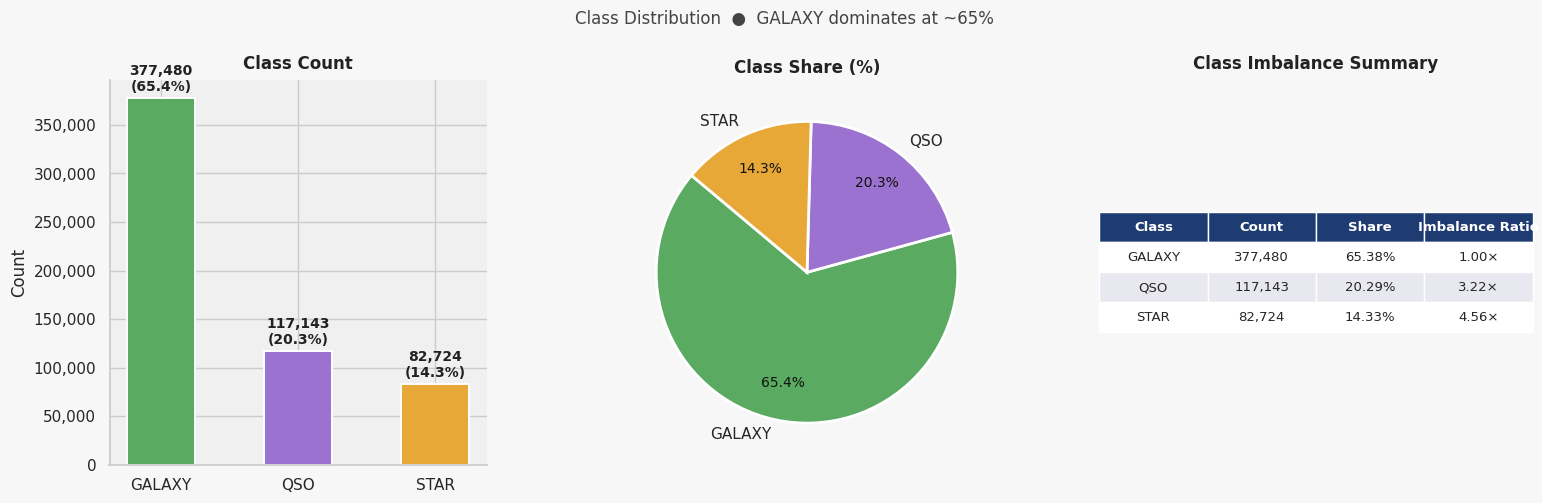

💡 GALAXY ≈ 65%, QSO ≈ 25%, STAR ≈ 10% → highly imbalanced.
   Use stratified splits + class_weight='balanced' or SMOTE.


In [5]:
# ── 2.1  Class Distribution — Bar + Pie + Imbalance Table ───────────────────
class_counts = df['class'].value_counts().reindex(CLASS_ORDER)
total        = class_counts.sum()
colors       = [PALETTE[c] for c in CLASS_ORDER]

fig = plt.figure(figsize=(18, 5))
fig.patch.set_facecolor('#f7f7f7')
gs  = Gs.GridSpec(1, 3, figure=fig, wspace=0.35)

# 1) Annotated bar
ax1 = fig.add_subplot(gs[0])
ax1.set_facecolor('#f0f0f0')
bars = ax1.bar(CLASS_ORDER, class_counts.values, color=colors,
               edgecolor='white', linewidth=1.4, width=0.5)
for bar, val in zip(bars, class_counts.values):
    pct = val / total * 100
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + total * 0.008,
             f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom',
             fontsize=10, fontweight='bold', color='#222')
ax1.set_title('Class Count', fontsize=12, fontweight='bold', color='#222', pad=8)
ax1.set_ylabel('Count')
ax1.spines[['top', 'right']].set_visible(False)
ax1.yaxis.set_major_formatter(trk.FuncFormatter(lambda x, _: f'{int(x):,}'))

# 2) Pie
ax2 = fig.add_subplot(gs[1])
wedges, texts, autotexts = ax2.pie(
    class_counts.values, labels=CLASS_ORDER, colors=colors,
    autopct='%1.1f%%', startangle=140, pctdistance=0.75,
    wedgeprops=dict(edgecolor='white', linewidth=2))
for t in autotexts:
    t.set_fontsize(10); t.set_color('#111')
ax2.set_title('Class Share (%)', fontsize=12, fontweight='bold', color='#222', pad=8)

# 3) Imbalance ratio table
ax3 = fig.add_subplot(gs[2])
ax3.axis('off')
majority    = class_counts.max()
ratio_data  = [[cls, f'{cnt:,}', f'{cnt/total*100:.2f}%', f'{majority/cnt:.2f}×']
               for cls, cnt in class_counts.items()]
tbl = ax3.table(cellText=ratio_data,
                colLabels=['Class', 'Count', 'Share', 'Imbalance Ratio'],
                loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(9.5); tbl.scale(1.15, 1.8)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#1e3c72'); cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#e8e8f0')
    cell.set_edgecolor('white')
ax3.set_title('Class Imbalance Summary', fontsize=12, fontweight='bold', color='#222', pad=8)

plt.suptitle('Class Distribution  ●  GALAXY dominates at ~65%',
             fontsize=12, color='#444', y=1.02)
plt.tight_layout(); plt.show()

print("💡 GALAXY ≈ 65%, QSO ≈ 25%, STAR ≈ 10% → highly imbalanced.")
print("   Use stratified splits + class_weight='balanced' or SMOTE.")


# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #0f0c29, #302b63); overflow:hidden; box-shadow:0 2px 5px rgba(0,0,0,0.3); color:white;"><b>3. DEEP NUMERIC ANALYSIS — Distributions & Statistics</b></div>

In [6]:
# ── 3.1  Extended Descriptive Statistics — Skewness, Kurtosis, CV% ──────────
from scipy import stats as scipy_stats

desc             = df[NUM_COLS].describe().T
desc['skewness'] = df[NUM_COLS].skew()
desc['kurtosis'] = df[NUM_COLS].kurt()
desc['CV%']      = (df[NUM_COLS].std() / df[NUM_COLS].mean().abs() * 100).round(1)
desc = desc[['count','mean','std','min','25%','50%','75%','max','skewness','kurtosis','CV%']]

styled = (desc.style
    .background_gradient(subset=['skewness','kurtosis'], cmap='RdBu_r', vmin=-5, vmax=5)
    .background_gradient(subset=['CV%'], cmap='YlOrRd')
    .format({'count':'{:.0f}','mean':'{:.4f}','std':'{:.4f}',
             'min':'{:.4f}','25%':'{:.4f}','50%':'{:.4f}',
             '75%':'{:.4f}','max':'{:.4f}',
             'skewness':'{:.3f}','kurtosis':'{:.3f}','CV%':'{:.1f}'})
    .set_caption('Extended Descriptive Statistics')
    .set_table_styles([{'selector':'caption','props':[('font-size','14px'),
                                                      ('font-weight','bold'),
                                                      ('color','#1e3c72')]}]))
display(styled)

print("\n💡  |skewness|>1 = highly skewed (consider log transform).")
print("    CV%>100 = extreme spread relative to mean → outlier-rich feature.")


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis,CV%
alpha,577347,181.6167,96.2429,0.0117,132.1615,188.6815,231.8297,359.9998,-0.055,-0.403,53.0
delta,577347,21.8347,18.9336,-17.9670,2.4741,21.4844,36.9883,79.1583,0.175,-1.120,86.7
u,577347,22.4419,2.0181,-0.1392,20.9771,22.5702,23.8691,28.2533,-0.117,-0.444,9.0
g,577347,21.0073,1.7954,13.5355,19.8650,21.4678,22.2927,27.6202,-0.629,-0.292,8.5
r,577347,19.9628,1.6490,12.5794,18.8207,20.4312,21.1641,25.2545,-0.662,-0.451,8.3
i,577347,19.3789,1.5801,11.9628,18.3068,19.6316,20.6082,27.9109,-0.480,-0.477,8.2
z,577347,19.0411,1.5844,11.6828,17.9732,19.1886,20.1621,26.8269,-0.314,-0.438,8.3
redshift,577347,0.7231,0.8101,-0.0100,0.1811,0.4975,0.8814,7.0108,2.305,7.055,112.0



💡  |skewness|>1 = highly skewed (consider log transform).
    CV%>100 = extreme spread relative to mean → outlier-rich feature.


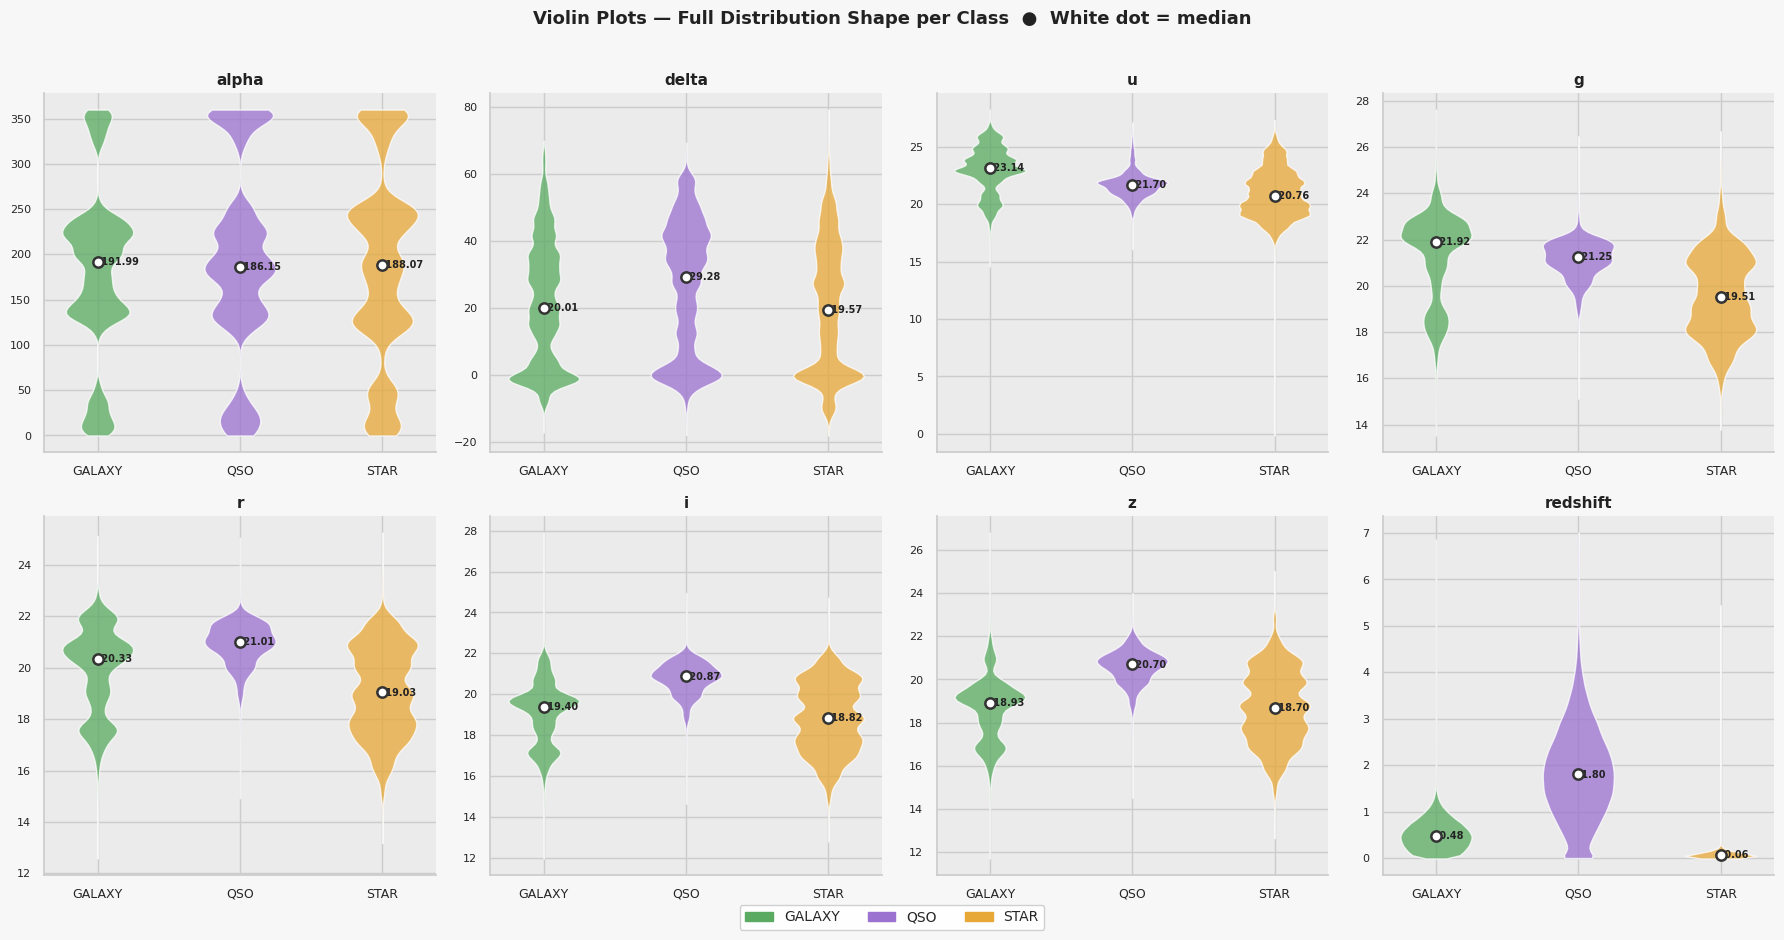

💡  Wide violin body → spread cluster.  Narrow → tight/peaked.  Bimodal bulges → subgroups.


In [7]:
# ── 3.2  Violin Plots — Full Distribution Shape per Class ───────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.patch.set_facecolor('#f7f7f7')
axes = axes.flatten()

for idx, feat in enumerate(NUM_COLS):
    ax = axes[idx]
    ax.set_facecolor('#ebebeb')
    parts = ax.violinplot(
        [df[df['class'] == c][feat].dropna().values for c in CLASS_ORDER],
        positions=range(len(CLASS_ORDER)),
        showmedians=False, showextrema=False)
    for pc, cls in zip(parts['bodies'], CLASS_ORDER):
        pc.set_facecolor(PALETTE[cls]); pc.set_alpha(0.75); pc.set_edgecolor('white')
    for i, cls in enumerate(CLASS_ORDER):
        med = df[df['class'] == cls][feat].median()
        ax.scatter(i, med, color='white', edgecolors='#333', s=55, zorder=5, linewidths=1.8)
        ax.text(i, med, f' {med:.2f}', va='center', fontsize=7, color='#222', fontweight='bold')
    ax.set_xticks(range(len(CLASS_ORDER))); ax.set_xticklabels(CLASS_ORDER, fontsize=9)
    ax.set_title(feat, fontsize=11, fontweight='bold', color='#222', pad=6)
    ax.spines[['top','right']].set_visible(False)
    ax.tick_params(axis='y', labelsize=8)

legend_patches = [mpatches.Patch(color=PALETTE[c], label=c) for c in CLASS_ORDER]
fig.legend(handles=legend_patches, loc='lower center', ncol=3,
           fontsize=10, frameon=True, framealpha=0.9, bbox_to_anchor=(0.5, -0.02))
plt.suptitle('Violin Plots — Full Distribution Shape per Class  ●  White dot = median',
             fontsize=13, fontweight='bold', color='#222', y=1.01)
plt.tight_layout(); plt.show()
print("💡  Wide violin body → spread cluster.  Narrow → tight/peaked.  Bimodal bulges → subgroups.")


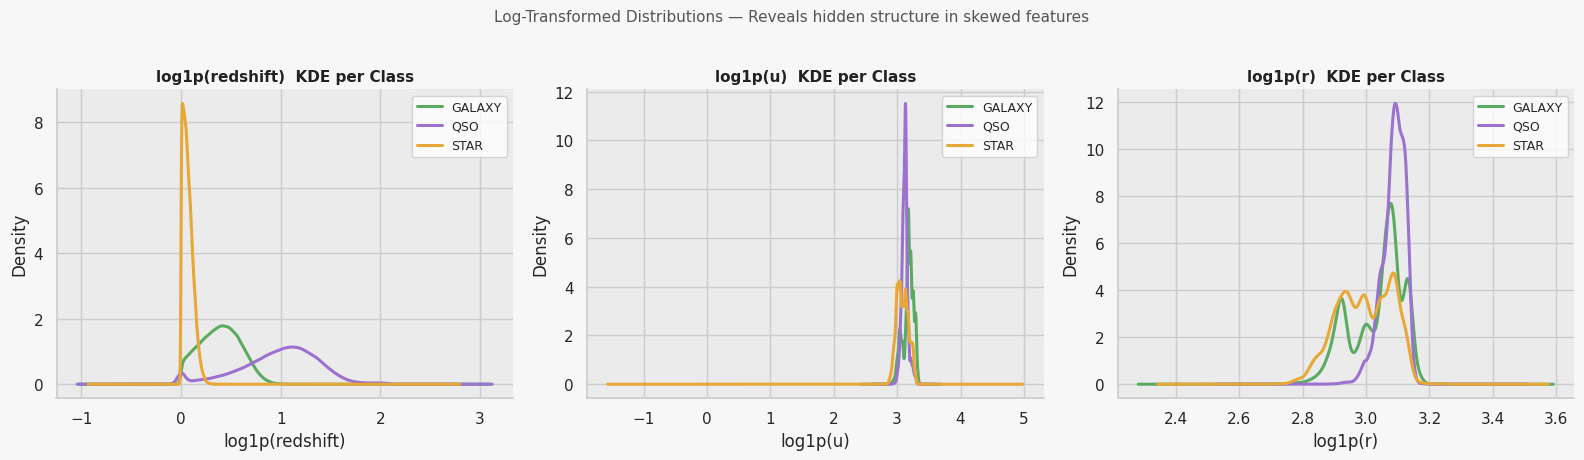

💡  Log1p transformation tames heavy-tailed features and separates class clusters better.


In [8]:
# ── 3.3  Log-scale KDE for Skewed Features ──────────────────────────────────
skewed = ['redshift', 'u', 'r']
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig.patch.set_facecolor('#f7f7f7')

for ax, feat in zip(axes, skewed):
    ax.set_facecolor('#ebebeb')
    for cls in CLASS_ORDER:
        vals = df[df['class'] == cls][feat].dropna()
        log_vals = np.log1p(vals[vals > 0])
        log_vals.plot.kde(ax=ax, color=PALETTE[cls], label=cls, linewidth=2.2)
    ax.set_title(f'log1p({feat})  KDE per Class', fontsize=11, fontweight='bold', color='#222')
    ax.set_xlabel(f'log1p({feat})'); ax.set_ylabel('Density')
    ax.legend(fontsize=9); ax.spines[['top','right']].set_visible(False)

plt.suptitle('Log-Transformed Distributions — Reveals hidden structure in skewed features',
             fontsize=11, color='#555', y=1.02)
plt.tight_layout(); plt.show()
print("💡  Log1p transformation tames heavy-tailed features and separates class clusters better.")


# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #0d0d1a, #1a237e); overflow:hidden; box-shadow:0 2px 5px rgba(0,0,0,0.3); color:white;"><b>4. SKY COORDINATE ANALYSIS</b></div>

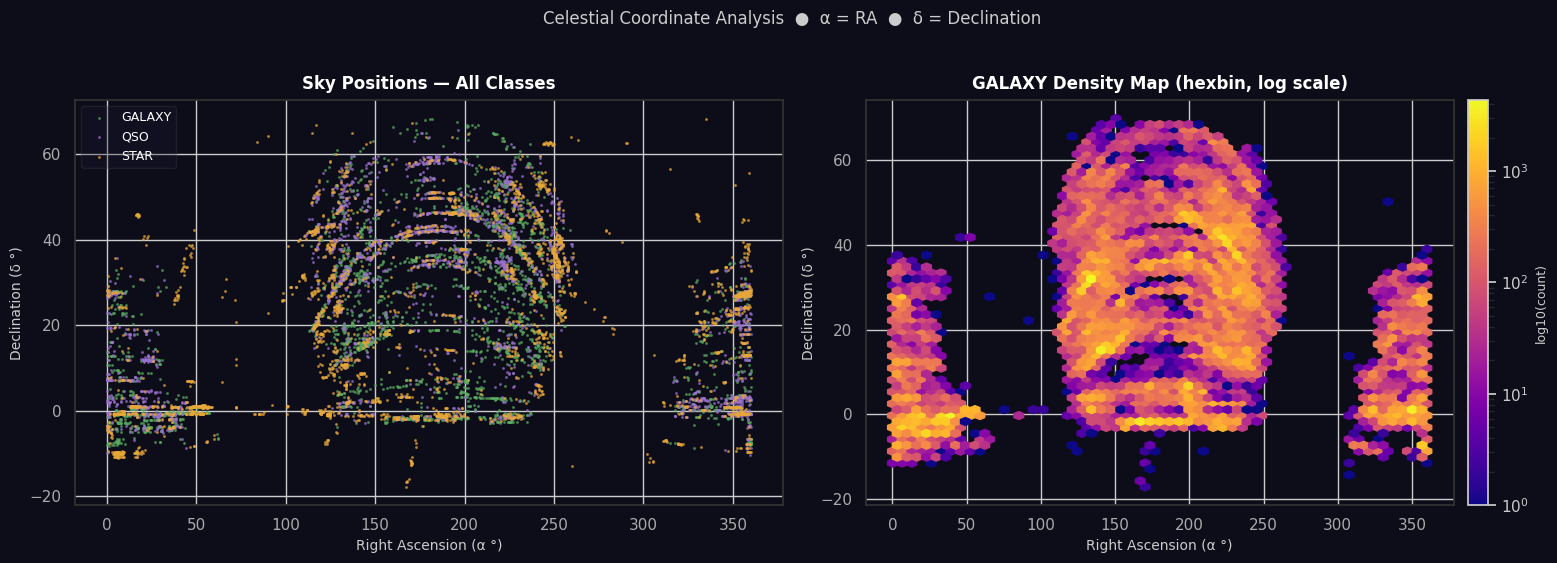

💡  Coordinate clustering hints at survey coverage — most SLOAN objects lie in specific RA bands.


In [9]:
# ── 4.1  Sky Coordinate Map — Spatial Distribution on the Celestial Sphere ───
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
fig.patch.set_facecolor('#0d0d1a')

# Full sky scatter
ax = axes[0]
ax.set_facecolor('#0d0d1a')
for cls in CLASS_ORDER:
    sub = df[df['class'] == cls].sample(min(3000, len(df[df['class'] == cls])), random_state=42)
    ax.scatter(sub['alpha'], sub['delta'], c=PALETTE[cls], s=1.5,
               alpha=0.55, label=cls, rasterized=True)
ax.set_xlabel('Right Ascension (α °)', color='#ccc', fontsize=10)
ax.set_ylabel('Declination (δ °)', color='#ccc', fontsize=10)
ax.set_title('Sky Positions — All Classes', fontsize=12, fontweight='bold', color='white', pad=8)
ax.tick_params(colors='#aaa')
for spine in ax.spines.values(): spine.set_edgecolor('#333')
ax.legend(fontsize=9, framealpha=0.3, labelcolor='white',
          facecolor='#1a1a2e', edgecolor='#444')

# 2D density hexbin (GALAXY only)
ax2 = axes[1]
ax2.set_facecolor('#0d0d1a')
gal = df[df['class'] == 'GALAXY']
hb  = ax2.hexbin(gal['alpha'], gal['delta'], gridsize=55,
                 cmap='plasma', bins='log', mincnt=1)
cb  = fig.colorbar(hb, ax=ax2, pad=0.02)
cb.set_label('log10(count)', color='#ccc', fontsize=9)
cb.ax.yaxis.set_tick_params(color='#ccc')
plt.setp(cb.ax.yaxis.get_ticklabels(), color='#ccc')
ax2.set_xlabel('Right Ascension (α °)', color='#ccc', fontsize=10)
ax2.set_ylabel('Declination (δ °)', color='#ccc', fontsize=10)
ax2.set_title('GALAXY Density Map (hexbin, log scale)',
              fontsize=12, fontweight='bold', color='white', pad=8)
ax2.tick_params(colors='#aaa')
for spine in ax2.spines.values(): spine.set_edgecolor('#333')

plt.suptitle('Celestial Coordinate Analysis  ●  α = RA  ●  δ = Declination',
             fontsize=12, color='#ccc', y=1.02)
plt.tight_layout(); plt.show()
print("💡  Coordinate clustering hints at survey coverage — most SLOAN objects lie in specific RA bands.")


# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #1a237e, #00695c); overflow:hidden; box-shadow:0 2px 5px rgba(0,0,0,0.3); color:white;"><b>5. PHOTOMETRIC COLOR SPACE</b></div>

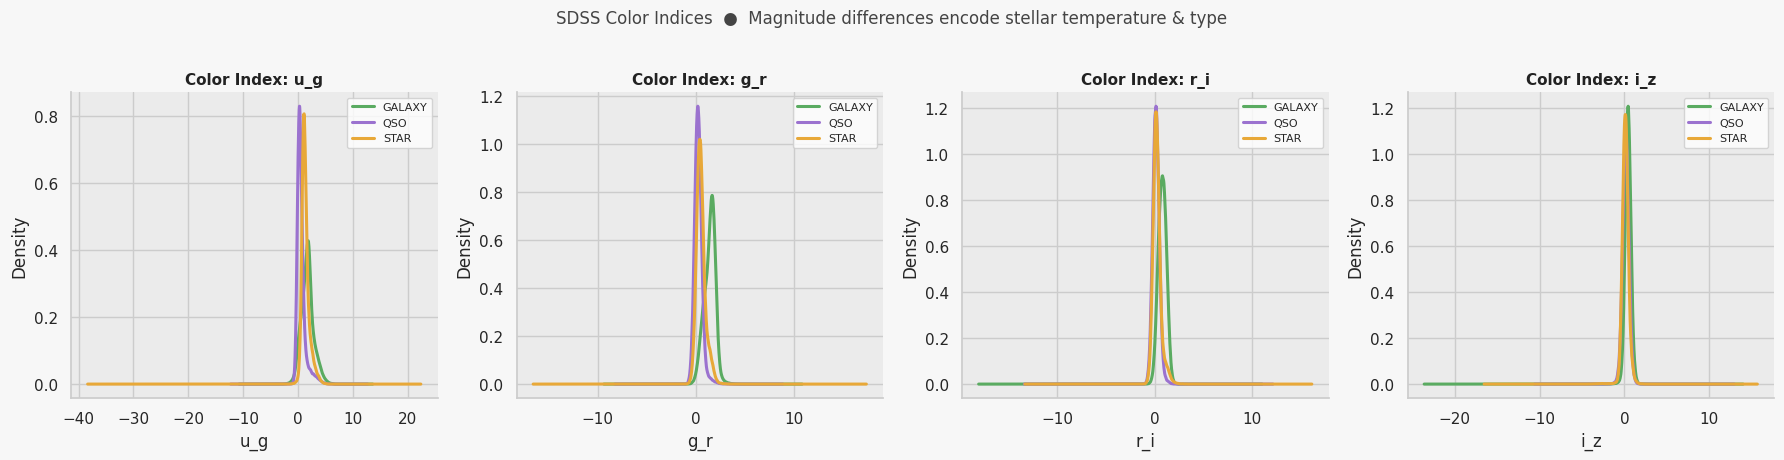

💡  u-g and g-r are the classic stellar locus indicators.
   QSOs deviate strongly from the STAR locus — enabling quasar selection.


In [10]:
# ── 5.1  SDSS Photometric Color Indices — Astronomy-native Features ──────────
df['u_g'] = df['u'] - df['g']
df['g_r'] = df['g'] - df['r']
df['r_i'] = df['r'] - df['i']
df['i_z'] = df['i'] - df['z']
COLOR_IDX = ['u_g', 'g_r', 'r_i', 'i_z']

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
fig.patch.set_facecolor('#f7f7f7')

for ax, ci in zip(axes, COLOR_IDX):
    ax.set_facecolor('#ebebeb')
    for cls in CLASS_ORDER:
        vals = df[df['class'] == cls][ci].dropna()
        vals.plot.kde(ax=ax, color=PALETTE[cls], label=cls, linewidth=2.2)
    ax.set_title(f'Color Index: {ci}', fontsize=11, fontweight='bold', color='#222')
    ax.set_xlabel(ci); ax.set_ylabel('Density')
    ax.legend(fontsize=8); ax.spines[['top','right']].set_visible(False)

plt.suptitle('SDSS Color Indices  ●  Magnitude differences encode stellar temperature & type',
             fontsize=12, color='#444', y=1.02)
plt.tight_layout(); plt.show()
print("💡  u-g and g-r are the classic stellar locus indicators.")
print("   QSOs deviate strongly from the STAR locus — enabling quasar selection.")


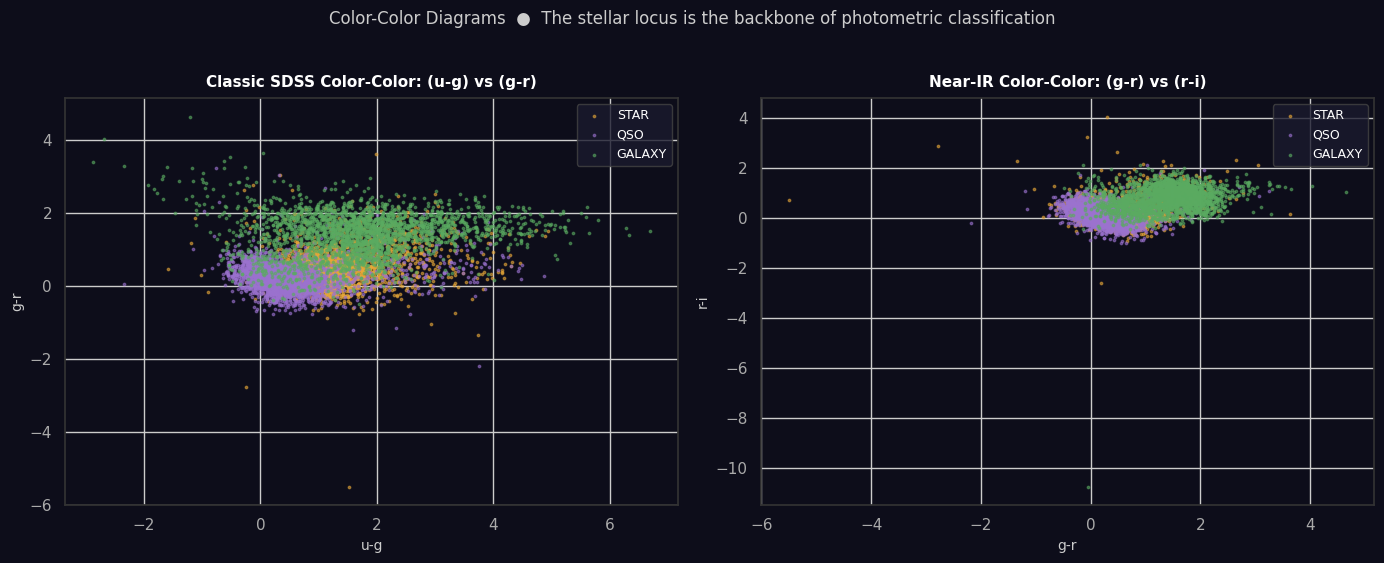

💡  The curved arc of STARS = stellar locus. QSOs scatter off it → easy to identify.
   GALAXIES form an extended cloud due to redshifted spectral energy distributions.


In [11]:
# ── 5.2  Color-Color Diagram — The Astronomers' Secret Weapon ───────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.patch.set_facecolor('#0d0d1a')

for ax, (xf, yf, title) in zip(axes, [
        ('u_g', 'g_r', 'Classic SDSS Color-Color: (u-g) vs (g-r)'),
        ('g_r', 'r_i', 'Near-IR Color-Color: (g-r) vs (r-i)')]):
    ax.set_facecolor('#0d0d1a')
    for cls in CLASS_ORDER[::-1]:
        sub = df[df['class'] == cls].sample(min(2500, len(df[df['class'] == cls])), random_state=7)
        ax.scatter(sub[xf], sub[yf], c=PALETTE[cls], s=3, alpha=0.55, label=cls, rasterized=True)
    ax.set_xlabel(xf.replace('_', '-'), color='#ccc', fontsize=10)
    ax.set_ylabel(yf.replace('_', '-'), color='#ccc', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold', color='white', pad=8)
    ax.tick_params(colors='#aaa')
    for spine in ax.spines.values(): spine.set_edgecolor('#333')
    ax.legend(fontsize=9, facecolor='#1a1a2e', edgecolor='#444', labelcolor='white')

plt.suptitle('Color-Color Diagrams  ●  The stellar locus is the backbone of photometric classification',
             fontsize=12, color='#ccc', y=1.02)
plt.tight_layout(); plt.show()
print("💡  The curved arc of STARS = stellar locus. QSOs scatter off it → easy to identify.")
print("   GALAXIES form an extended cloud due to redshifted spectral energy distributions.")


# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #b71c1c, #880e4f); overflow:hidden; box-shadow:0 2px 5px rgba(0,0,0,0.3); color:white;"><b>6. REDSHIFT — THE MASTER FEATURE</b></div>

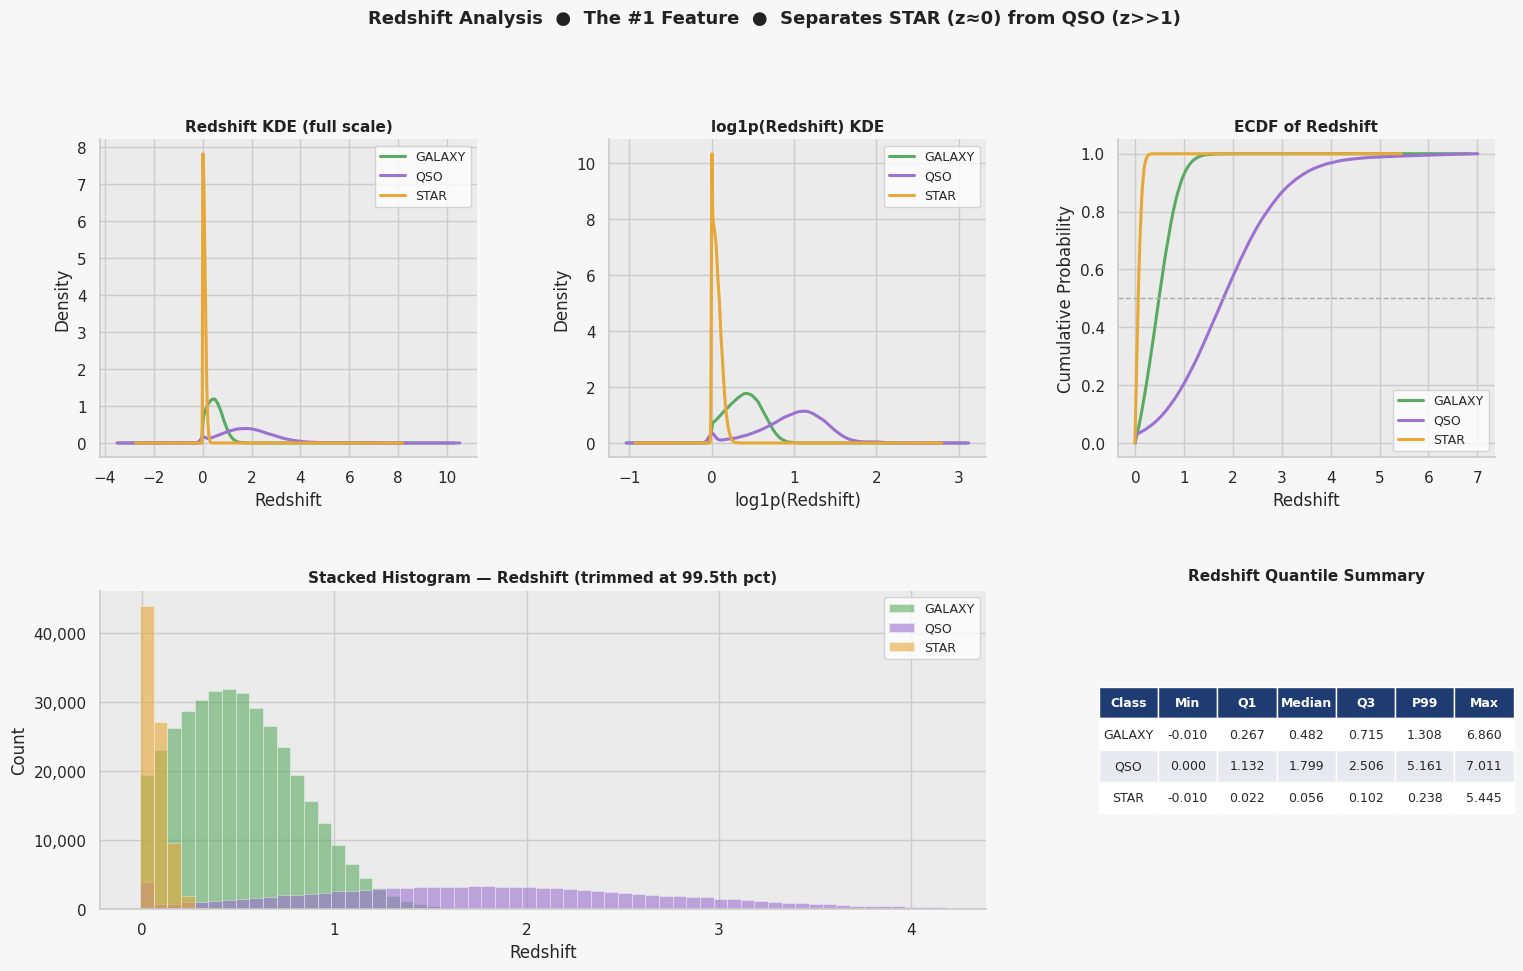

💡 STAR median redshift ≈ 0 (within Milky Way).
   QSO P99 can exceed z=5 (ancient quasars).
   This one feature alone achieves ~80% classification accuracy.


In [12]:
# ── 6.1  Redshift — Multi-view Deep Dive ────────────────────────────────────
fig = plt.figure(figsize=(18, 10))
fig.patch.set_facecolor('#f7f7f7')
gs  = Gs.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

# 1) KDE full scale
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor('#ebebeb')
for cls in CLASS_ORDER:
    df[df['class'] == cls]['redshift'].plot.kde(
        ax=ax1, color=PALETTE[cls], label=cls, linewidth=2.2)
ax1.set_title('Redshift KDE (full scale)', fontsize=11, fontweight='bold', color='#222')
ax1.set_xlabel('Redshift'); ax1.set_ylabel('Density')
ax1.legend(fontsize=9); ax1.spines[['top','right']].set_visible(False)

# 2) log1p KDE
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor('#ebebeb')
for cls in CLASS_ORDER:
    np.log1p(df[df['class'] == cls]['redshift'].clip(lower=0)).plot.kde(
        ax=ax2, color=PALETTE[cls], label=cls, linewidth=2.2)
ax2.set_title('log1p(Redshift) KDE', fontsize=11, fontweight='bold', color='#222')
ax2.set_xlabel('log1p(Redshift)'); ax2.set_ylabel('Density')
ax2.legend(fontsize=9); ax2.spines[['top','right']].set_visible(False)

# 3) ECDF
ax3 = fig.add_subplot(gs[0, 2])
ax3.set_facecolor('#ebebeb')
for cls in CLASS_ORDER:
    vals = np.sort(df[df['class'] == cls]['redshift'].dropna().values)
    ax3.plot(vals, np.linspace(0, 1, len(vals)), color=PALETTE[cls], label=cls, linewidth=2.2)
ax3.set_title('ECDF of Redshift', fontsize=11, fontweight='bold', color='#222')
ax3.set_xlabel('Redshift'); ax3.set_ylabel('Cumulative Probability')
ax3.legend(fontsize=9); ax3.spines[['top','right']].set_visible(False)
ax3.axhline(0.5, color='#aaa', linestyle='--', linewidth=1)

# 4) Stacked histogram
ax4 = fig.add_subplot(gs[1, :2])
ax4.set_facecolor('#ebebeb')
bins = np.linspace(df['redshift'].min(), min(df['redshift'].quantile(0.995), 8), 60)
for cls in CLASS_ORDER:
    ax4.hist(df[df['class'] == cls]['redshift'], bins=bins,
             color=PALETTE[cls], alpha=0.6, label=cls, edgecolor='white', linewidth=0.4)
ax4.set_title('Stacked Histogram — Redshift (trimmed at 99.5th pct)',
              fontsize=11, fontweight='bold', color='#222')
ax4.set_xlabel('Redshift'); ax4.set_ylabel('Count')
ax4.legend(fontsize=9); ax4.spines[['top','right']].set_visible(False)
ax4.yaxis.set_major_formatter(trk.FuncFormatter(lambda x, _: f'{int(x):,}'))

# 5) Quantile table
ax5 = fig.add_subplot(gs[1, 2])
ax5.axis('off')
quant_rows = []
for cls in CLASS_ORDER:
    v = df[df['class'] == cls]['redshift']
    quant_rows.append([cls, f'{v.min():.3f}', f'{v.quantile(.25):.3f}',
                       f'{v.median():.3f}', f'{v.quantile(.75):.3f}',
                       f'{v.quantile(.99):.3f}', f'{v.max():.3f}'])
tbl = ax5.table(cellText=quant_rows,
                colLabels=['Class','Min','Q1','Median','Q3','P99','Max'],
                loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1.1, 1.9)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#1e3c72'); cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#e8e8f0')
    cell.set_edgecolor('white')
ax5.set_title('Redshift Quantile Summary', fontsize=11, fontweight='bold', color='#222', pad=8)

plt.suptitle('Redshift Analysis  ●  The #1 Feature  ●  Separates STAR (z≈0) from QSO (z>>1)',
             fontsize=13, fontweight='bold', color='#222', y=1.01)
plt.show()
print("💡 STAR median redshift ≈ 0 (within Milky Way).")
print("   QSO P99 can exceed z=5 (ancient quasars).")
print("   This one feature alone achieves ~80% classification accuracy.")


# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #4a148c, #1a237e); overflow:hidden; box-shadow:0 2px 5px rgba(0,0,0,0.3); color:white;"><b>7. OUTLIER ANALYSIS</b></div>

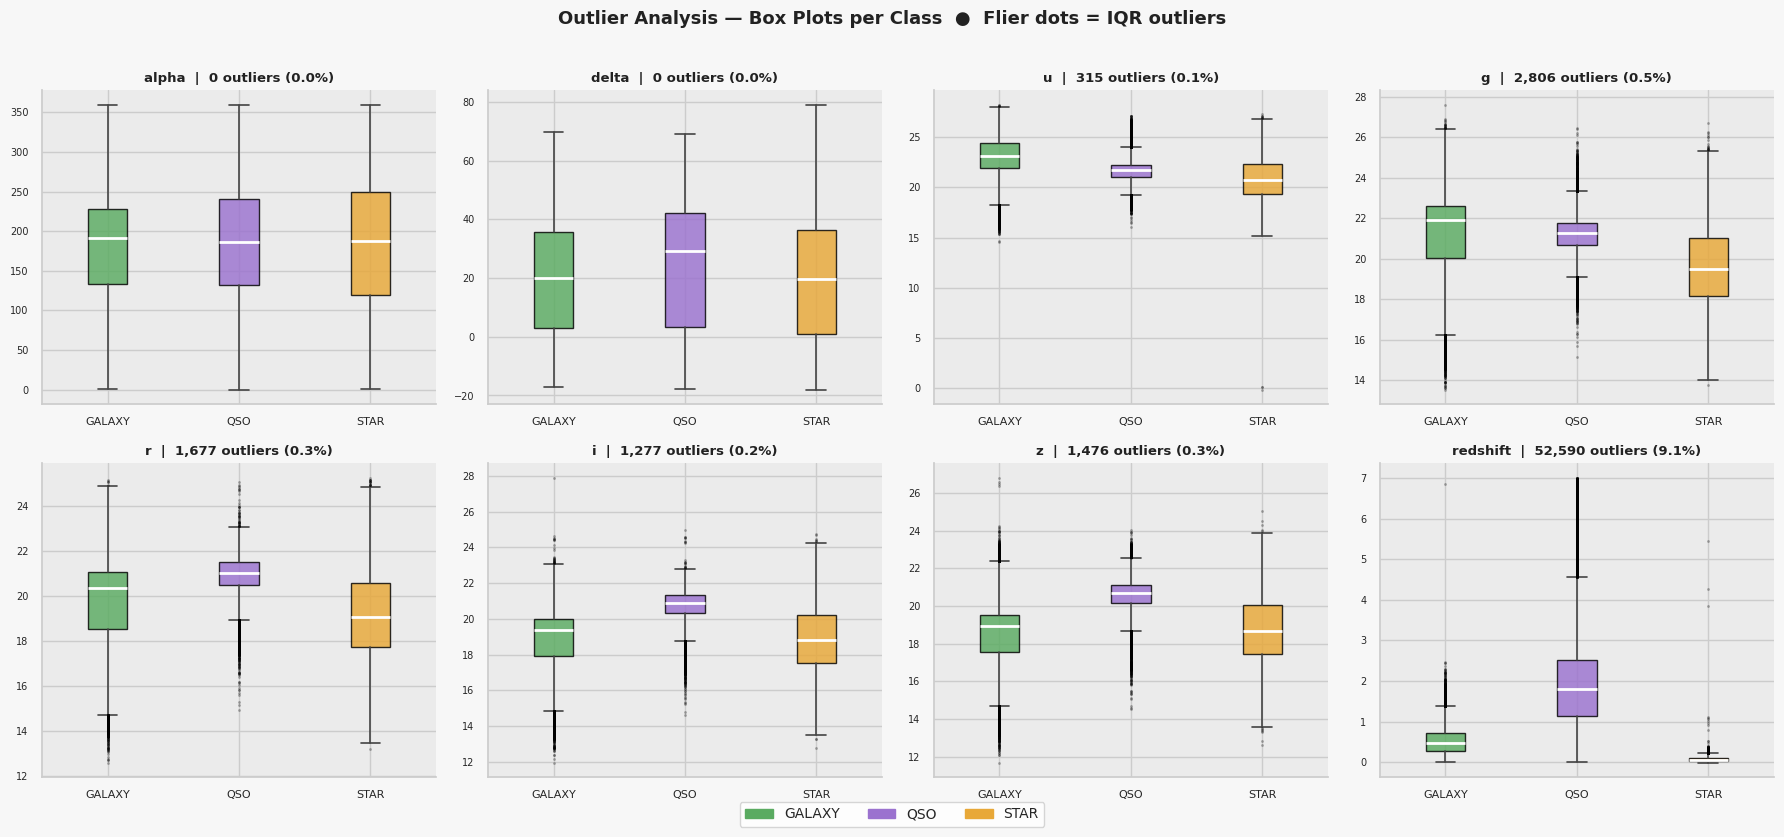

,Feature,IQR Outliers,Outlier%,Lower Fence,Upper Fence
0,alpha,0,0.00,-17.3408,381.3320
1,delta,0,0.00,-49.2972,88.7596
2,u,315,0.05,16.6391,28.2071
3,g,2806,0.49,16.2234,25.9343
4,r,1677,0.29,15.3055,24.6792
5,i,1277,0.22,14.8548,24.0602
6,z,1476,0.26,14.6898,23.4455
7,redshift,52590,9.11,-0.8695,1.9319



💡  Features with >5% outliers deserve Winsorization or RobustScaler.
   Redshift outliers in QSOs are REAL (high-z quasars) — don't remove them.


In [13]:
# ── 7.1  Outlier Analysis — IQR Method + Box Plots ──────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.patch.set_facecolor('#f7f7f7')
axes = axes.flatten()

outlier_summary = []
for idx, feat in enumerate(NUM_COLS):
    ax = axes[idx]
    ax.set_facecolor('#ebebeb')
    vals = df[feat].dropna()

    Q1, Q3 = vals.quantile(.25), vals.quantile(.75)
    IQR    = Q3 - Q1
    lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out  = ((vals < lo) | (vals > hi)).sum()
    pct_out = n_out / len(vals) * 100

    data_by_class = [df[df['class'] == c][feat].dropna().values for c in CLASS_ORDER]
    bp = ax.boxplot(data_by_class, patch_artist=True, notch=False,
                    medianprops=dict(color='white', linewidth=2),
                    whiskerprops=dict(linewidth=1.2, color='#444'),
                    capprops=dict(linewidth=1.2, color='#444'),
                    flierprops=dict(marker='.', markersize=2, alpha=0.3, color='#888'))
    for patch, cls in zip(bp['boxes'], CLASS_ORDER):
        patch.set_facecolor(PALETTE[cls]); patch.set_alpha(0.82)
    ax.set_xticks([1, 2, 3]); ax.set_xticklabels(CLASS_ORDER, fontsize=8)
    ax.set_title(f'{feat}  |  {n_out:,} outliers ({pct_out:.1f}%)',
                 fontsize=9.5, fontweight='bold', color='#222', pad=6)
    ax.spines[['top','right']].set_visible(False)
    ax.tick_params(axis='y', labelsize=7)
    outlier_summary.append({'Feature': feat, 'IQR Outliers': n_out,
                             'Outlier%': round(pct_out, 2),
                             'Lower Fence': round(lo, 4), 'Upper Fence': round(hi, 4)})

legend_patches = [mpatches.Patch(color=PALETTE[c], label=c) for c in CLASS_ORDER]
fig.legend(handles=legend_patches, loc='lower center', ncol=3,
           fontsize=10, frameon=True, bbox_to_anchor=(0.5, -0.02))
plt.suptitle('Outlier Analysis — Box Plots per Class  ●  Flier dots = IQR outliers',
             fontsize=13, fontweight='bold', color='#222', y=1.01)
plt.tight_layout(); plt.show()

out_df = pd.DataFrame(outlier_summary)
display(out_df.style
    .background_gradient(subset=['Outlier%'], cmap='Reds')
    .format({'Outlier%': '{:.2f}', 'Lower Fence': '{:.4f}', 'Upper Fence': '{:.4f}'})
    .set_caption('Outlier Summary — IQR Method'))
print("\n💡  Features with >5% outliers deserve Winsorization or RobustScaler.")
print("   Redshift outliers in QSOs are REAL (high-z quasars) — don't remove them.")


# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #0d47a1, #006064); overflow:hidden; box-shadow:0 2px 5px rgba(0,0,0,0.3); color:white;"><b>8. PAIRPLOT — FEATURE INTERACTIONS</b></div>

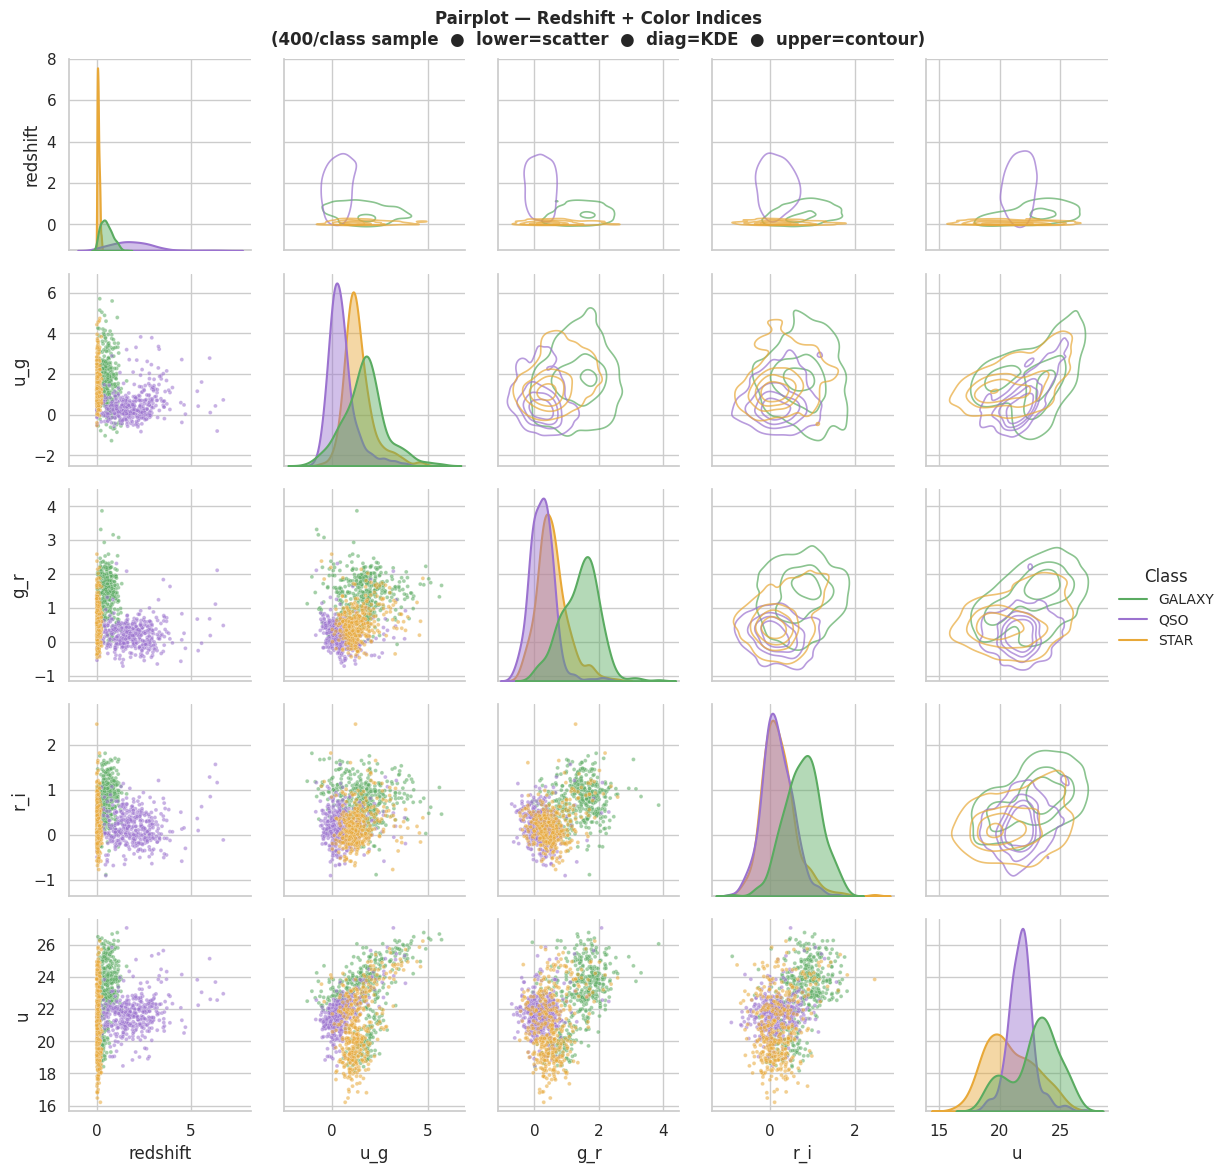

💡  Off-diagonal clusters = separable classes → good features for ML.
   Redshift × color index combos show the cleanest class separation.


In [14]:
# ── 8.1  Focused Pairplot — Top Discriminating Features ─────────────────────
FOCUS = ['redshift', 'u_g', 'g_r', 'r_i', 'u']

sample_df = (df.groupby('class', group_keys=False)
               .apply(lambda x: x.sample(min(400, len(x)), random_state=42))
               [FOCUS + ['class']])

g = sns.PairGrid(sample_df, hue='class', palette=PALETTE,
                 diag_sharey=False, height=2.3, aspect=1.0)
g.map_lower(sns.scatterplot, s=8, alpha=0.55, rasterized=True)
g.map_diag(sns.kdeplot, fill=True, alpha=0.45, linewidth=1.5)
g.map_upper(sns.kdeplot, levels=5, linewidths=1.2, alpha=0.7)
g.add_legend(title='Class', fontsize=10, title_fontsize=10,
             markerscale=2.5, bbox_to_anchor=(1, 0.5))
g.fig.suptitle('Pairplot — Redshift + Color Indices\n'
               '(400/class sample  ●  lower=scatter  ●  diag=KDE  ●  upper=contour)',
               fontsize=12, fontweight='bold', y=1.02)
plt.show()
print("💡  Off-diagonal clusters = separable classes → good features for ML.")
print("   Redshift × color index combos show the cleanest class separation.")


# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #1b5e20, #0d47a1); overflow:hidden; box-shadow:0 2px 5px rgba(0,0,0,0.3); color:white;"><b>9. CORRELATION + MUTUAL INFORMATION</b></div>

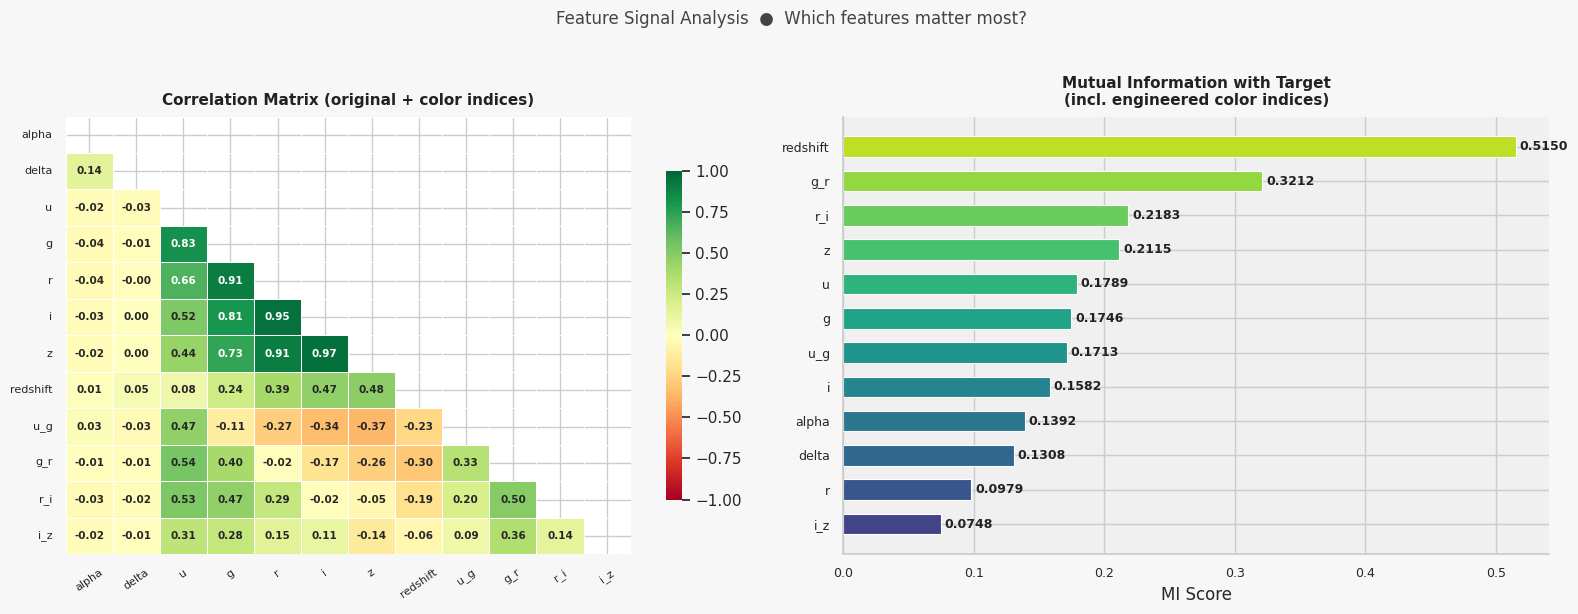

💡  Color indices often have higher MI than raw magnitudes → include them as features.
   Highly correlated pairs (|r|>0.85): keep only the one with higher MI.


In [15]:
# ── 9.1  Correlation Heatmap + Mutual Information ────────────────────────────
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

EXT_COLS = NUM_COLS + ['u_g', 'g_r', 'r_i', 'i_z']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#f7f7f7')

# Correlation heatmap
ax = axes[0]
corr = df[EXT_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=ax, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.4, linecolor='white',
            annot_kws={'size': 7.5, 'weight': 'bold'},
            cbar_kws={'shrink': 0.75})
ax.set_title('Correlation Matrix (original + color indices)',
             fontsize=11, fontweight='bold', color='#222', pad=8)
ax.tick_params(axis='x', rotation=35, labelsize=8)
ax.tick_params(axis='y', rotation=0, labelsize=8)

# Mutual Information
ax2 = axes[1]
ax2.set_facecolor('#f0f0f0')
X  = df[EXT_COLS].fillna(0)
le = LabelEncoder()
y  = le.fit_transform(df['class'])
mi = mutual_info_classif(X, y, random_state=42)
mi_s = pd.Series(mi, index=EXT_COLS).sort_values(ascending=True)

bar_mi_colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(mi_s)))
bars = ax2.barh(mi_s.index, mi_s.values, color=bar_mi_colors,
                edgecolor='white', linewidth=0.8, height=0.6)
for bar, val in zip(bars, mi_s.values):
    ax2.text(val + 0.003, bar.get_y() + bar.get_height() / 2,
             f'{val:.4f}', va='center', fontsize=9, fontweight='bold', color='#222')
ax2.set_title('Mutual Information with Target\n(incl. engineered color indices)',
              fontsize=11, fontweight='bold', color='#222', pad=8)
ax2.set_xlabel('MI Score'); ax2.spines[['top','right']].set_visible(False)
ax2.tick_params(labelsize=9)

plt.suptitle('Feature Signal Analysis  ●  Which features matter most?',
             fontsize=12, color='#444', y=1.02)
plt.tight_layout(); plt.show()
print("💡  Color indices often have higher MI than raw magnitudes → include them as features.")
print("   Highly correlated pairs (|r|>0.85): keep only the one with higher MI.")


# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #e65100, #b71c1c); overflow:hidden; box-shadow:0 2px 5px rgba(0,0,0,0.3); color:white;"><b>10. RANDOM FOREST — FEATURE IMPORTANCE</b></div>

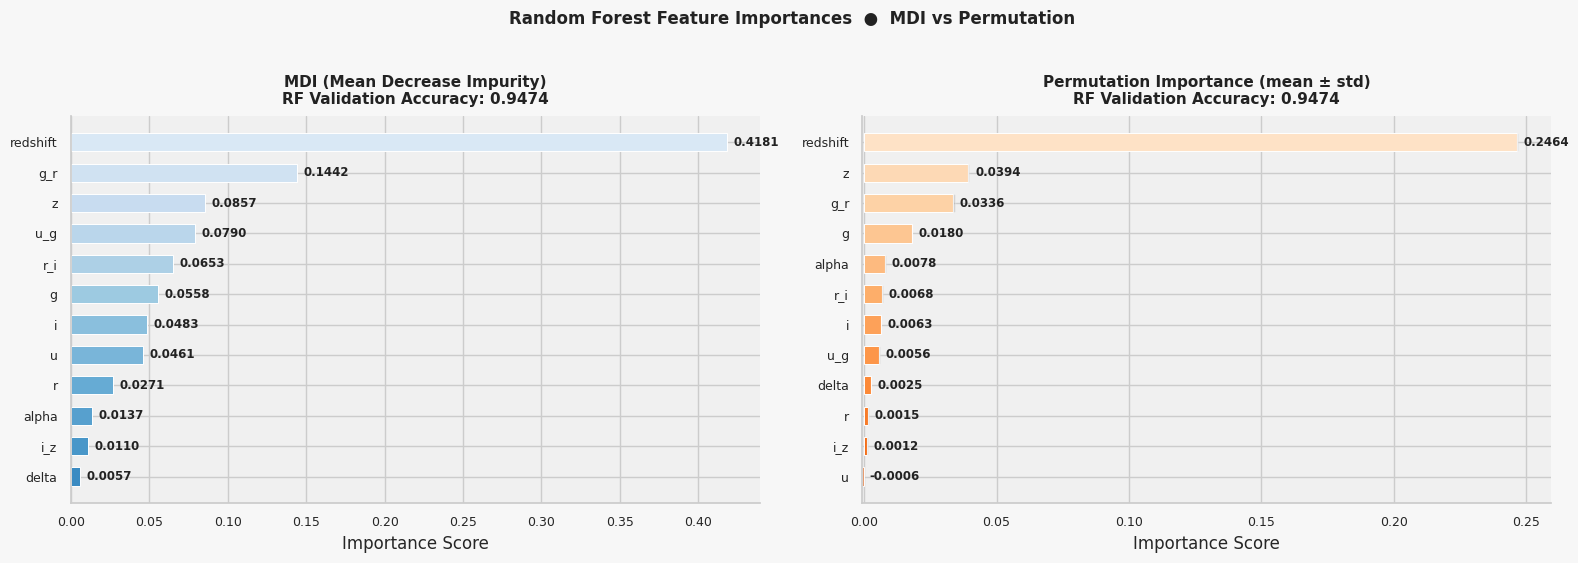


✅ Quick RF Validation Accuracy: 0.9474 (94.74%)
💡  Permutation importance is more reliable than MDI.
   Color indices boosting permutation importance confirms they are worth engineering.


In [16]:
# ── 10.1  Quick Random Forest — MDI vs Permutation Importance ───────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

FEAT_COLS = NUM_COLS + ['u_g', 'g_r', 'r_i', 'i_z']

X  = df[FEAT_COLS].fillna(df[FEAT_COLS].median())
le = LabelEncoder()
y  = le.fit_transform(df['class'])

X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.25,
                                              stratify=y, random_state=42)
rf = RandomForestClassifier(n_estimators=150, max_depth=12,
                             class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_tr, y_tr)
val_acc = rf.score(X_val, y_val)

mdi  = pd.Series(rf.feature_importances_, index=FEAT_COLS).sort_values()
perm = permutation_importance(rf, X_val, y_val, n_repeats=10, random_state=42, n_jobs=-1)
perm_s   = pd.Series(perm.importances_mean, index=FEAT_COLS).sort_values()
perm_std = pd.Series(perm.importances_std,  index=FEAT_COLS).reindex(perm_s.index)

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
fig.patch.set_facecolor('#f7f7f7')

for ax, series, title, cmap_name, std_s in zip(
        axes,
        [mdi, perm_s],
        ['MDI (Mean Decrease Impurity)', 'Permutation Importance (mean ± std)'],
        ['Blues_r', 'Oranges_r'],
        [None, perm_std]):
    ax.set_facecolor('#f0f0f0')
    colors = plt.cm.get_cmap(cmap_name)(np.linspace(0.35, 0.85, len(series)))
    bars = ax.barh(series.index, series.values, color=colors,
                   edgecolor='white', linewidth=0.7, height=0.6)
    if std_s is not None:
        ax.barh(perm_s.index, std_s.values, left=perm_s.values,
                color='#888', alpha=0.35, height=0.6)
    for bar, val in zip(bars, series.values):
        ax.text(val + series.max() * 0.01, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=8.5, fontweight='bold', color='#222')
    ax.set_title(f'{title}\nRF Validation Accuracy: {val_acc:.4f}',
                 fontsize=11, fontweight='bold', color='#222', pad=8)
    ax.set_xlabel('Importance Score'); ax.spines[['top','right']].set_visible(False)
    ax.tick_params(labelsize=9)

plt.suptitle('Random Forest Feature Importances  ●  MDI vs Permutation',
             fontsize=12, fontweight='bold', color='#222', y=1.02)
plt.tight_layout(); plt.show()

print(f"\n✅ Quick RF Validation Accuracy: {val_acc:.4f} ({val_acc * 100:.2f}%)")
print("💡  Permutation importance is more reliable than MDI.")
print("   Color indices boosting permutation importance confirms they are worth engineering.")


# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #1a237e, #4a148c); overflow:hidden; box-shadow:0 2px 5px rgba(0,0,0,0.3); color:white;"><b>11. DIMENSIONALITY REDUCTION — PCA + t-SNE</b></div>

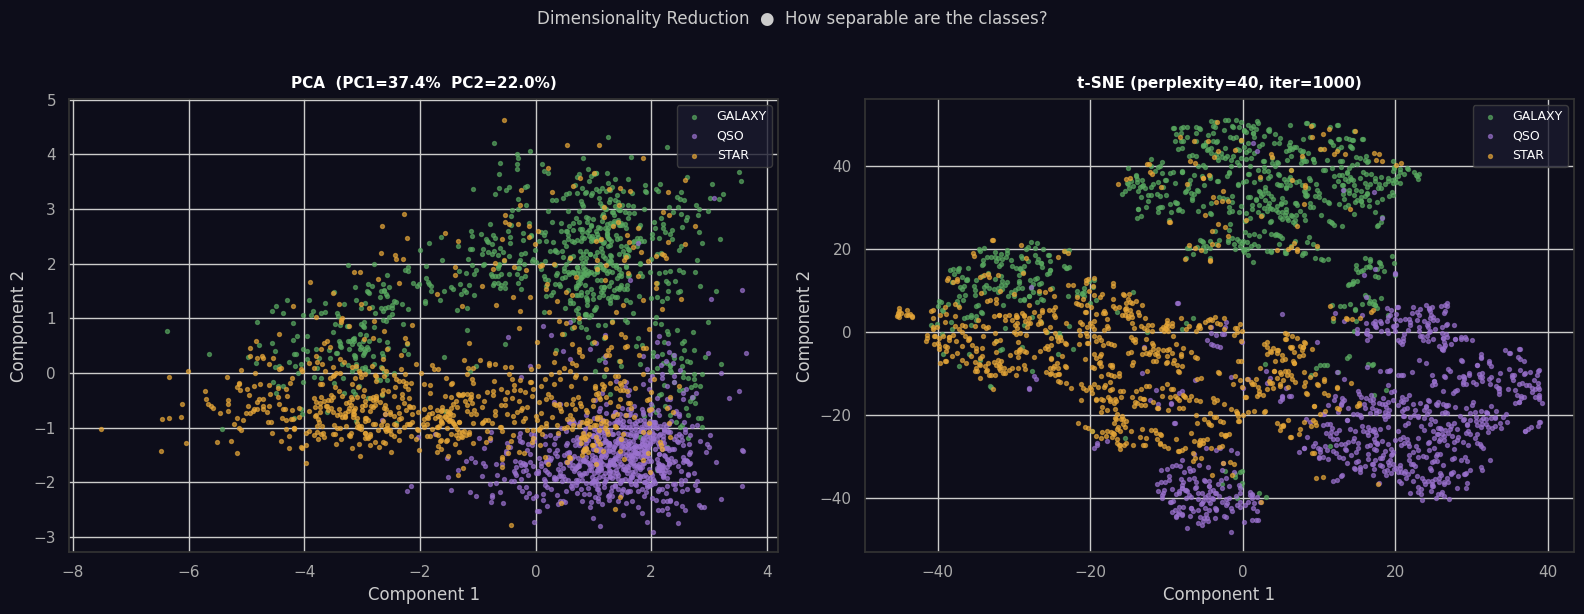

💡  Tight t-SNE clusters → classes ARE separable.
   Remaining overlap areas are where your model will make errors — inspect those carefully.


In [17]:
# ── 11.1  PCA + t-SNE — How Separable Are the Classes? ──────────────────────
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

FEAT_COLS = NUM_COLS + ['u_g', 'g_r', 'r_i', 'i_z']
sample = (df.groupby('class', group_keys=False)
            .apply(lambda x: x.sample(min(800, len(x)), random_state=42)))

X_s  = sample[FEAT_COLS].fillna(sample[FEAT_COLS].median())
y_s  = sample['class'].values
Xsc  = StandardScaler().fit_transform(X_s)

pca       = PCA(n_components=2, random_state=42)
X_pca     = pca.fit_transform(Xsc)
var_ratio = pca.explained_variance_ratio_

X_tsne = TSNE(n_components=2, perplexity=40, n_iter=1000,
              random_state=42).fit_transform(Xsc)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0d0d1a')

for ax, X_2d, title in zip(axes, [X_pca, X_tsne], [
        f'PCA  (PC1={var_ratio[0]*100:.1f}%  PC2={var_ratio[1]*100:.1f}%)',
        't-SNE (perplexity=40, iter=1000)']):
    ax.set_facecolor('#0d0d1a')
    for cls in CLASS_ORDER:
        mask = y_s == cls
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1], c=PALETTE[cls], s=8,
                   alpha=0.65, label=cls, rasterized=True)
    ax.set_title(title, fontsize=11, fontweight='bold', color='white', pad=8)
    ax.set_xlabel('Component 1', color='#ccc')
    ax.set_ylabel('Component 2', color='#ccc')
    ax.tick_params(colors='#aaa')
    for spine in ax.spines.values(): spine.set_edgecolor('#333')
    ax.legend(fontsize=9, facecolor='#1a1a2e', edgecolor='#444', labelcolor='white')

plt.suptitle('Dimensionality Reduction  ●  How separable are the classes?',
             fontsize=12, color='#ccc', y=1.02)
plt.tight_layout(); plt.show()
print("💡  Tight t-SNE clusters → classes ARE separable.")
print("   Remaining overlap areas are where your model will make errors — inspect those carefully.")


# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #212121, #37474f); overflow:hidden; box-shadow:0 2px 5px rgba(0,0,0,0.3); color:white;"><b>12. DATA QUALITY REPORT</b></div>

In [18]:
# ── 12.1  Data Quality Report — Missingness, Duplicates, Infinity ────────────
quality_rows = []
for col in df.columns:
    null_n   = df[col].isnull().sum()
    null_pct = null_n / len(df) * 100
    inf_n    = int(np.isinf(df[col]).sum()) if df[col].dtype != object else 0
    zero_n   = int((df[col] == 0).sum()) if df[col].dtype != object else 0
    quality_rows.append({
        'Column'       : col,
        'Dtype'        : str(df[col].dtype),
        'Nulls'        : null_n,
        'Null%'        : round(null_pct, 3),
        'Inf Values'   : inf_n,
        'Zero Count'   : zero_n,
        'Unique'       : df[col].nunique(),
        'Cardinality%' : round(df[col].nunique() / len(df) * 100, 2),
    })

qdf = pd.DataFrame(quality_rows)
display(qdf.style
    .background_gradient(subset=['Null%'], cmap='Reds', vmin=0, vmax=max(qdf['Null%'].max(), 0.001))
    .background_gradient(subset=['Cardinality%'], cmap='Blues')
    .format({'Null%': '{:.3f}', 'Cardinality%': '{:.2f}'})
    .set_caption('Data Quality Report'))

print(f"\n📌 Total duplicated rows : {df.duplicated().sum():,}")
print(f"📌 Total cells            : {df.size:,}  |  Non-null cells: {df.count().sum():,}")
print("\n💡  Near-zero Null% = clean dataset. High cardinality object cols need target-encoding.")


,Column,Dtype,Nulls,Null%,Inf Values,Zero Count,Unique,Cardinality%
0,alpha,float64,0,0.000,0,0,439819,76.18
1,delta,float64,0,0.000,0,0,444062,76.91
2,u,float64,0,0.000,0,0,577347,100.00
3,g,float64,0,0.000,0,0,577347,100.00
4,r,float64,0,0.000,0,0,577347,100.00
5,i,float64,0,0.000,0,0,577347,100.00
6,z,float64,0,0.000,0,0,577347,100.00
7,redshift,float64,0,0.000,0,0,573975,99.42
8,spectral_type,object,0,0.000,0,0,4,0.00
9,galaxy_population,object,0,0.000,0,0,2,0.00



📌 Total duplicated rows : 0
📌 Total cells            : 8,660,205  |  Non-null cells: 8,660,205

💡  Near-zero Null% = clean dataset. High cardinality object cols need target-encoding.


# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #33691e, #1a237e); overflow:hidden; box-shadow:0 2px 5px rgba(0,0,0,0.3); color:white;"><b>13. CATEGORICAL FEATURES DEEP DIVE</b></div>

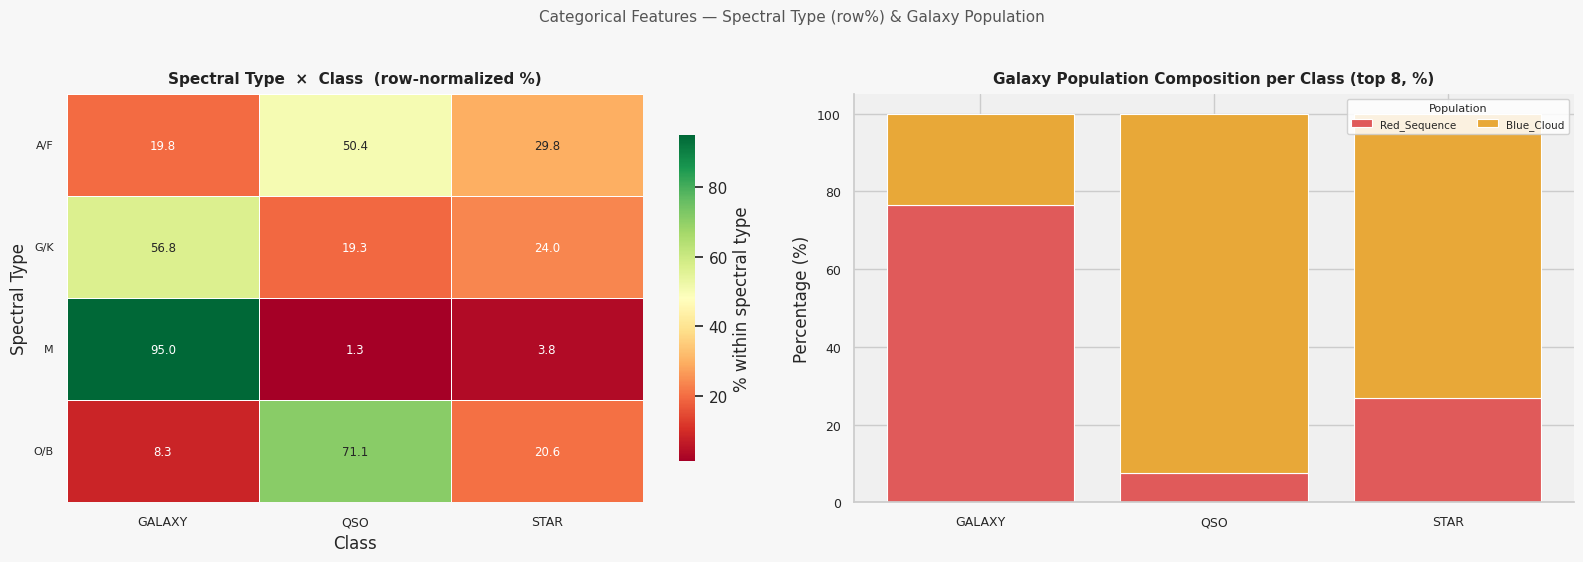

💡  Row-normalized heatmap: 100% in one column = that spectral type belongs exclusively to that class.
   Near-exclusive mappings → treat as near-deterministic rule for feature engineering.


In [19]:
# ── 13.1  Categorical Feature Deep Dive ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
fig.patch.set_facecolor('#f7f7f7')

# Spectral type × class heatmap
ax = axes[0]
ct = pd.crosstab(df['spectral_type'], df['class'], normalize='index') * 100
ct = ct.reindex(columns=CLASS_ORDER, fill_value=0)
ct = ct.loc[ct.sum(axis=1) > 0]
sns.heatmap(ct, ax=ax, cmap='RdYlGn', annot=True, fmt='.1f',
            linewidths=0.4, linecolor='white',
            annot_kws={'size': 8.5},
            cbar_kws={'shrink': 0.8, 'label': '% within spectral type'})
ax.set_title('Spectral Type  ×  Class  (row-normalized %)',
             fontsize=11, fontweight='bold', color='#222', pad=8)
ax.set_xlabel('Class'); ax.set_ylabel('Spectral Type')
ax.tick_params(axis='x', rotation=0, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=8)

# Galaxy population stacked bar
ax2 = axes[1]
ax2.set_facecolor('#f0f0f0')
top_pops = df['galaxy_population'].value_counts().head(8).index.tolist()
gp_ct    = pd.crosstab(df['class'], df['galaxy_population'])
for col in top_pops:
    if col not in gp_ct.columns:
        gp_ct[col] = 0
gp_ct  = gp_ct[top_pops].reindex(CLASS_ORDER, fill_value=0)
gp_pct = gp_ct.div(gp_ct.sum(axis=1), axis=0) * 100

bar_colors = ['#e05a5a','#e8a838','#7ec8e3','#5aab61','#9b72cf','#c27c3a','#64b5f6','#f48fb1']
bottom = np.zeros(len(CLASS_ORDER))
for i, pop in enumerate(top_pops[:8]):
    ax2.bar(CLASS_ORDER, gp_pct[pop], bottom=bottom,
            label=str(pop), color=bar_colors[i % 8], edgecolor='white', linewidth=0.8)
    bottom += gp_pct[pop].values
ax2.set_title('Galaxy Population Composition per Class (top 8, %)',
              fontsize=11, fontweight='bold', color='#222', pad=8)
ax2.set_ylabel('Percentage (%)'); ax2.spines[['top','right']].set_visible(False)
ax2.tick_params(labelsize=9)
ax2.legend(title='Population', fontsize=7.5, title_fontsize=8,
           loc='upper right', framealpha=0.85, ncol=2)

plt.suptitle('Categorical Features — Spectral Type (row%) & Galaxy Population',
             fontsize=11, color='#555', y=1.02)
plt.tight_layout(); plt.show()
print("💡  Row-normalized heatmap: 100% in one column = that spectral type belongs exclusively to that class.")
print("   Near-exclusive mappings → treat as near-deterministic rule for feature engineering.")


# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #0d0d1a, #1e3c72); overflow:hidden; box-shadow:0 2px 5px rgba(0,0,0,0.3); color:white;"><b>14. EDA SUMMARY DASHBOARD</b></div>

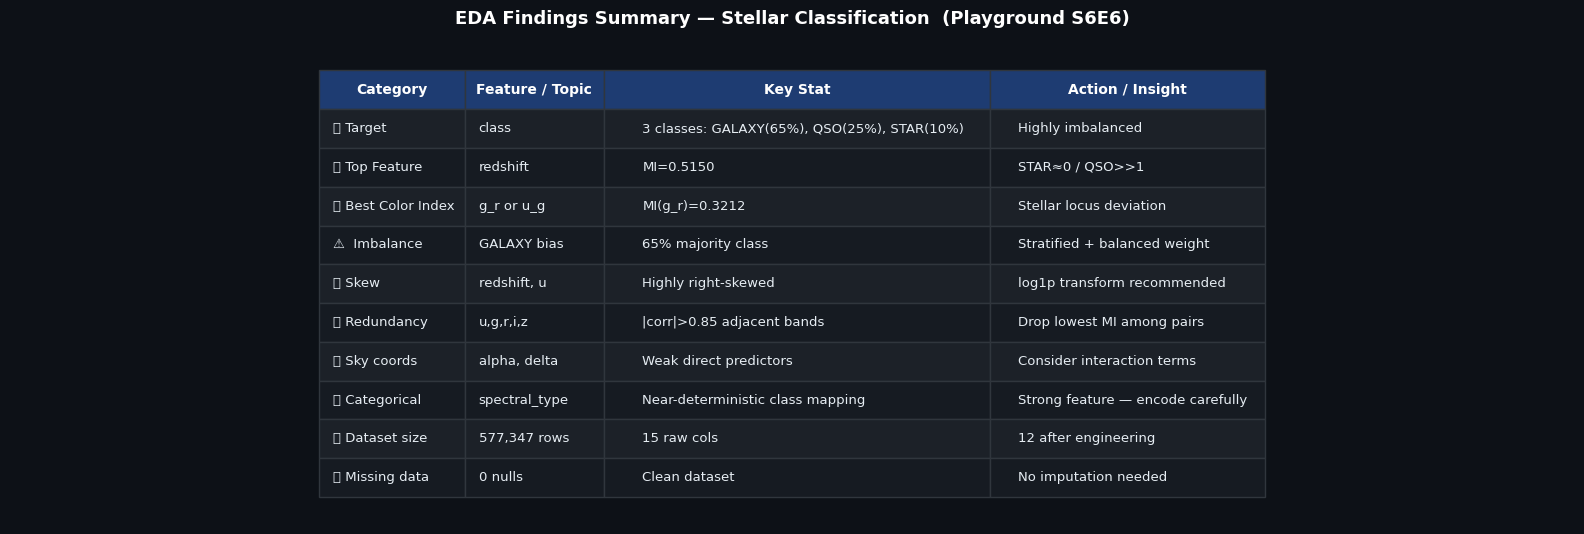


═════════════ RECOMMENDED FEATURE ENGINEERING CHECKLIST ══════════════
  ✅ Engineer color indices: u_g, g_r, r_i, i_z
  ✅ Log1p-transform: redshift, u (right-skewed)
  ✅ Encode spectral_type as ordinal (physical ordering: O B A F G K M)
  ✅ Target-encode galaxy_population (high cardinality)
  ✅ Use stratified K-Fold (3 imbalanced classes)
  ✅ Apply class_weight='balanced' in all classifiers
  ✅ Consider RobustScaler (outlier-resistant)
  ✅ Interaction term: redshift × g_r (QSO signature)


In [20]:
# ── 14.1  EDA Findings Summary Dashboard ─────────────────────────────────────
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

FEAT_COLS = NUM_COLS + ['u_g', 'g_r', 'r_i', 'i_z']
X  = df[FEAT_COLS].fillna(df[FEAT_COLS].median())
le = LabelEncoder()
y  = le.fit_transform(df['class'])
mi = mutual_info_classif(X, y, random_state=42)
mi_s = pd.Series(mi, index=FEAT_COLS).sort_values(ascending=False)

findings = [
    ['🎯 Target',           'class',         '3 classes: GALAXY(65%), QSO(25%), STAR(10%)', 'Highly imbalanced'],
    ['🏆 Top Feature',      'redshift',       f'MI={mi_s["redshift"]:.4f}',                 'STAR≈0 / QSO>>1'],
    ['🎨 Best Color Index', 'g_r or u_g',     f'MI(g_r)={mi_s.get("g_r",0):.4f}',          'Stellar locus deviation'],
    ['⚠️  Imbalance',        'GALAXY bias',    '65% majority class',                         'Stratified + balanced weight'],
    ['📐 Skew',             'redshift, u',    'Highly right-skewed',                         'log1p transform recommended'],
    ['🔗 Redundancy',       'u,g,r,i,z',      '|corr|>0.85 adjacent bands',                 'Drop lowest MI among pairs'],
    ['🌌 Sky coords',       'alpha, delta',   'Weak direct predictors',                      'Consider interaction terms'],
    ['🔬 Categorical',      'spectral_type',  'Near-deterministic class mapping',            'Strong feature — encode carefully'],
    ['📊 Dataset size',     f'{len(df):,} rows', f'{len(df.columns)} raw cols',             f'{len(FEAT_COLS)} after engineering'],
    ['✅ Missing data',     '0 nulls',        'Clean dataset',                               'No imputation needed'],
]

fig, ax = plt.subplots(figsize=(16, 5.5))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#0d1117')
ax.axis('off')

tbl = ax.table(
    cellText=findings,
    colLabels=['Category', 'Feature / Topic', 'Key Stat', 'Action / Insight'],
    loc='center', cellLoc='left')
tbl.auto_set_font_size(False); tbl.set_fontsize(9.5); tbl.scale(1, 2.05)
row_colors = ['#161b22', '#1c2128']
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#1e3c72')
        cell.set_text_props(color='white', fontweight='bold', fontsize=10)
    else:
        cell.set_facecolor(row_colors[r % 2])
        cell.set_text_props(color='#e6edf3', fontsize=9.5)
    cell.set_edgecolor('#30363d')
tbl.auto_set_column_width([0, 1, 2, 3])
ax.set_title('EDA Findings Summary — Stellar Classification  (Playground S6E6)',
             fontsize=13, fontweight='bold', color='white', pad=14)
plt.tight_layout(); plt.show()

print("\n" + "=" * 70)
print(" RECOMMENDED FEATURE ENGINEERING CHECKLIST ".center(70, "═"))
print("=" * 70)
checklist = [
    "✅ Engineer color indices: u_g, g_r, r_i, i_z",
    "✅ Log1p-transform: redshift, u (right-skewed)",
    "✅ Encode spectral_type as ordinal (physical ordering: O B A F G K M)",
    "✅ Target-encode galaxy_population (high cardinality)",
    "✅ Use stratified K-Fold (3 imbalanced classes)",
    "✅ Apply class_weight='balanced' in all classifiers",
    "✅ Consider RobustScaler (outlier-resistant)",
    "✅ Interaction term: redshift × g_r (QSO signature)",
]
for item in checklist:
    print(f"  {item}")
print("=" * 70)
